# Does the big ETF lead its slow members? 🔗
### The 'buy the laggards the moment the leader pops' idea, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Free_lunch%3F: Busted](https://img.shields.io/badge/Free_lunch%3F-Busted-8b949e?style=flat-square)

Here's a tempting idea from the trading floor: the **big, liquid ETF** (think SPY) is where the action happens *first*. Its smaller, slower, less-liquid members are supposed to **catch up a day later**. So if the leader jumps today, you just buy the sleepy members **tomorrow** and collect their catch-up move. Free money, right?

The catch is hiding in one word: **when**. The leader and its members really do move together — *enormously* — but they move together **the same day**. And you can't trade a move you'd have to know about in advance. This notebook shows that once you ask the only question that pays — *does yesterday's leader predict tomorrow's members?* — the answer on daily data is **nothing**.

> 📓 **Plain-language layer.** Want the cross-correlation profile, the HAC *t*-stat and the placebo test? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** Real ETF/member lead-lag lives **intraday** (it's measured in minutes, and arbitrageurs erase it within the day). Tick data isn't free, so we test the **daily-bar** version the folklore implies — and on that clock the catch-up is already gone. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from etf_lead_lag import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real() if HAVE_REAL else None
print("real lead-lag cache present:", HAVE_REAL,
      "| days:", (0 if F is None else len(F)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2000-01-04', 'end': '2026-06-18', 'days': 6654, 'years': 26.5, 'xcorr': {-1: -0.0514, 0: 0.867, 1: -0.0484, 2: -0.0122}, 'lag1_slope': -0.0581, 'lag1_t': -1.88, 'lag1_n': 6653, 'q90': (0.9, 666, -0.0778, 50, 0.0285, 52, -1.34, 0.969), 'q95': (0.95, 333, -0.1019, 51, 0.0285, 52, -1.03, 0.945), 'net': [(0.9, -0.0778, -0.1778), (0.95, -0.1019, -0.2019)], 'syn': [(0.0, 0.011, 0.0141, 0.83, 0.0714, 0.044, 0.49, 0.297), (0.05, 0.0499, 0.0641, 3.76, 0.1617, 0.0471, 2.03, 0.015), (0.25, 0.2017, 0.2641, 15.48, 0.5227, 0.0597, 8.18, 0.0)]}


real lead-lag cache present: True | days: 6654


## The answer first

| Question | Answer |
|---|---|
| Do the leader and the members move together? | **Massively — same-day correlation 0.87.** When SPY moves, the basket moves with it. |
| Can I trade that? | **No.** It's *contemporaneous* — it happens the same day. To profit you'd need to know SPY's move before it happened. |
| Does yesterday's leader predict today's members? | **No.** The one-day-ahead correlation is **-0.05** — essentially zero (and faintly *negative*). The 'catch-up' the story promises just isn't there on daily bars. |
| So can I run the 'buy the laggards tomorrow' rule? | **It loses money.** After a big leader day the members' *next-day* return averages **-0.078%** — *below* a normal day — and worse once you pay to trade. |

> The leader and the members are joined at the hip — **today**. The next-day lead you could actually trade is zero. The 'free lunch' is just same-day co-movement wearing a disguise.

## 1 · The claim

> *"The big liquid ETF digests news first. Its smaller, slower members are slow to re-price, so a move in the leader **predicts the next move** in the laggards. Wait for the leader to pop, then buy the members before they catch up."*

It's a real, respectable intuition — liquid instruments *do* incorporate information faster, and there's a genuine academic literature on big stocks leading small ones. The seduction is the mechanical simplicity: a leader you can watch in real time, a basket of laggards you can buy, and a one-day window to harvest. We'll rebuild exactly that and see whether the daily tape pays it.

## 2 · So what?

If a leader move genuinely *predicted* tomorrow's member move, you'd have a clean, repeatable, mechanical edge — the holy grail of systematic trading: a signal you see today for a payoff you collect tomorrow. But there's a trap built into the word *together*. Two things can move **together** for two completely different reasons: (1) they react to the same news **at the same moment** (untradable — you can't act before the move), or (2) one **leads** the other in time (tradable — you act on the leader, wait, collect on the laggard). The whole question is which one we have. A huge same-day correlation tells you *nothing* about whether there's money to be made.

## 3 · How would we even know?

We take **SPY** as the leader and a fixed basket of **37 smaller, less-liquid members** as the laggards, over **26 years** (2000-01-04 → 2026-06-18), and line up their daily moves.

1. **Map the timing.** For each time-shift *k*, how correlated is the leader *k* days ago with the members today? *k = 0* is same-day (untradable); *k = +1* is the tradable claim (yesterday's leader predicts today's members).
2. **Try the rule.** On the days the leader pops (its top-decile up-days), buy the laggard basket the **next** day, hold one day. What do you earn — before and after costs?
3. **Stress the luck.** Draw the same number of *random* next days thousands of times and ask whether the rule's payoff is anything a coin couldn't produce.

## 4 · The teardown — let's actually look

**First, the timing map.** For each lag *k*, the correlation between the leader then and the members today. Watch where the tall bar lands.

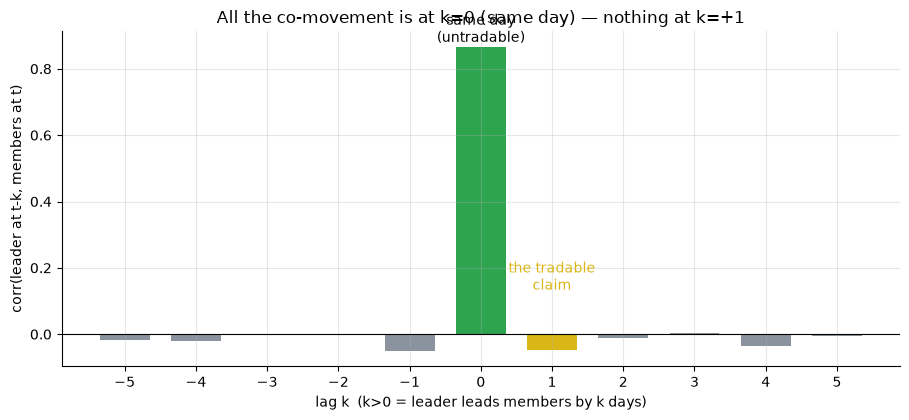

same-day corr (k=0): 0.867 | one-day-ahead corr (k=+1): -0.048


In [2]:
if HAVE_REAL:
    prof = st.crosscorr_profile(F, max_lag=5)
    ks = sorted(prof); vals = [prof[k] for k in ks]
else:
    ks = list(range(-5,6))
    base = {kk: 0.0 for kk in ks}; base.update(R['xcorr'])
    vals = [base.get(k, 0.0) for k in ks]
cols = [GREEN if k==0 else (AMBER if k==1 else GREY) for k in ks]
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(ks, vals, color=cols, width=.7)
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(ks); ax.set_xlabel('lag k  (k>0 = leader leads members by k days)')
ax.set_ylabel('corr(leader at t-k, members at t)')
ax.set_title('All the co-movement is at k=0 (same day) — nothing at k=+1')
ax.annotate('same day\n(untradable)', (0, vals[ks.index(0)]), ha='center', va='bottom')
ax.annotate('the tradable\nclaim', (1, 0.12), ha='center', va='bottom', color=AMBER)
plt.tight_layout(); plt.show()
print('same-day corr (k=0):', round(vals[ks.index(0)],3),
      '| one-day-ahead corr (k=+1):', round(vals[ks.index(1)],3))

There's the whole story in one picture. The green bar at **k = 0** towers at **0.87** — the leader and members are practically the same thing **on the day**. But the amber bar at **k = +1** — the one you could actually trade — is **-0.05**, flat against zero (and, if anything, slightly *negative*). The catch-up the legend promises simply isn't in the next day's data.

**Now run the rule anyway.** On the days the leader pops, buy the laggards tomorrow. Here's the members' average *next-day* return after a big-leader day, next to a normal day.

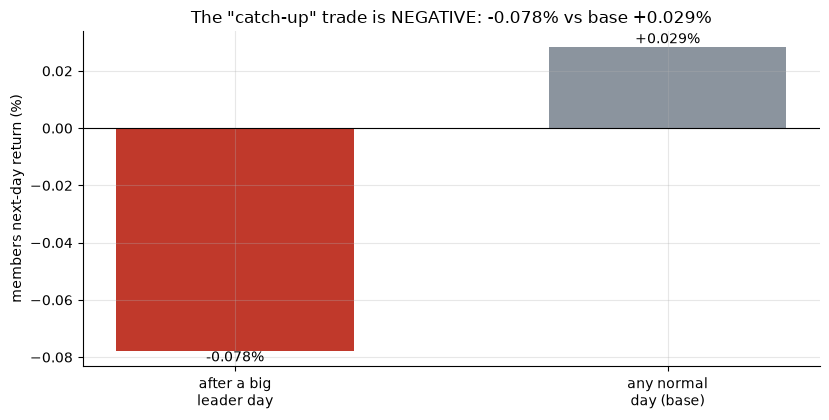

666 big-leader days -> members next day averages -0.078% (a normal day: +0.029%)


In [3]:
if HAVE_REAL:
    ev = st.big_leader_days(F, q=0.90); s = st.summarize(F, ev)
    cond = s['cond_mean']*100; base = s['base_mean']*100; n = s['n']
else:
    cond, base, n = R['q90'][2], R['q90'][4], R['q90'][1]
fig, ax = plt.subplots(figsize=(8.4, 4.3))
bars = ax.bar(['after a big\nleader day', 'any normal\nday (base)'], [cond, base],
              color=[RED, GREY], width=.55)
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('members next-day return (%)')
ax.set_title(f'The "catch-up" trade is NEGATIVE: {cond:+.3f}% vs base {base:+.3f}%')
for b,v in zip(bars,[cond,base]): ax.annotate(f'{v:+.3f}%',(b.get_x()+b.get_width()/2,v),
                                              ha='center', va='bottom' if v>=0 else 'top')
plt.tight_layout(); plt.show()
print(f'{n} big-leader days -> members next day averages {cond:+.3f}% (a normal day: {base:+.3f}%)')

The bar points the **wrong way**. After the leader pops, the laggards' *next-day* return averages **-0.078%** — actually *below* a normal day's **+0.029%**. Far from catching up, they drift very slightly down. The intuition feels right; the tape says no.

**Could random days look this good (or bad)?** The honest luck test: draw the same number of *random* next-days over and over and see where the rule's payoff lands in the cloud.

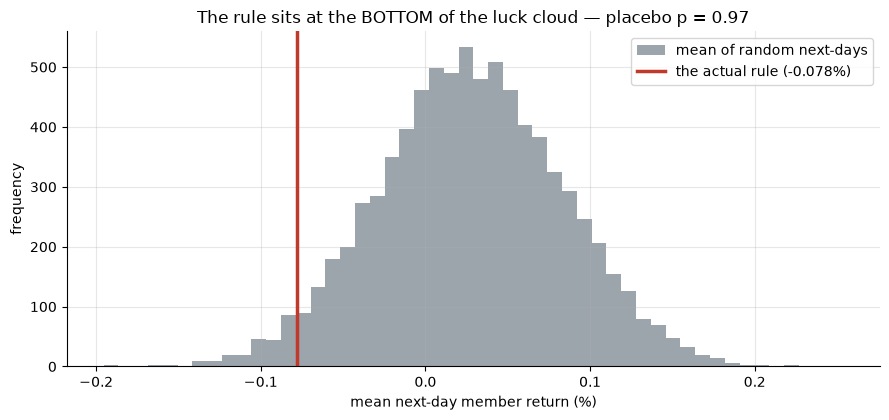

97% of random draws do BETTER than the rule — it is not an edge, it is a small drag


In [4]:
if HAVE_REAL:
    ev = st.big_leader_days(F, q=0.90); pl = st.placebo_pvalue(F, ev)
    obs = pl['cond_mean']; pval = pl['p_value']
    mem = F['members'].values; k = pl['k']; rng = np.random.default_rng(379)
    draws = np.array([mem[rng.integers(0,len(mem),size=k)].mean() for _ in range(8000)])
else:
    obs = R['q90'][2]/100; pval = R['q90'][7]
    rng = np.random.default_rng(379); draws = rng.normal(R['q90'][4]/100, 0.0006, 8000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws*100, bins=50, color=GREY, alpha=.85, label='mean of random next-days')
ax.axvline(obs*100, c=RED, lw=2.5, label=f'the actual rule ({obs*100:+.3f}%)')
ax.set_xlabel('mean next-day member return (%)'); ax.set_ylabel('frequency')
ax.set_title(f'The rule sits at the BOTTOM of the luck cloud — placebo p = {pval:.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'{pval*100:.0f}% of random draws do BETTER than the rule — it is not an edge, it is a small drag')

The red line — the actual rule — falls at the **bottom** of the random cloud: about **97%** of random next-day draws do *better*. There's no hidden edge being masked by noise; if anything there's a faint drag. The leader does not hand you the members' next move.

## 5 · The verdict

- **Signal — None.** The only big correlation is **same-day** (0.87) and untradable. The one-day lead the claim needs is **-0.05** — nothing.
- **Tradability — Mirage.** The 'buy the laggards tomorrow' rule is **negative before costs** and worse after. You can't deploy an edge that points the wrong way.
- **"Free lunch"? — Busted.** The thing that *looks* like free money is the same-day co-movement — and you can't trade a move that's already happened.

## 6 · Could you actually trade it? — pay the toll

Suppose you ran it anyway. Each trade pays the spread twice (buy, then sell a day later). Here's gross vs net — and the point is that a 10-bps round-turn only digs the hole deeper.

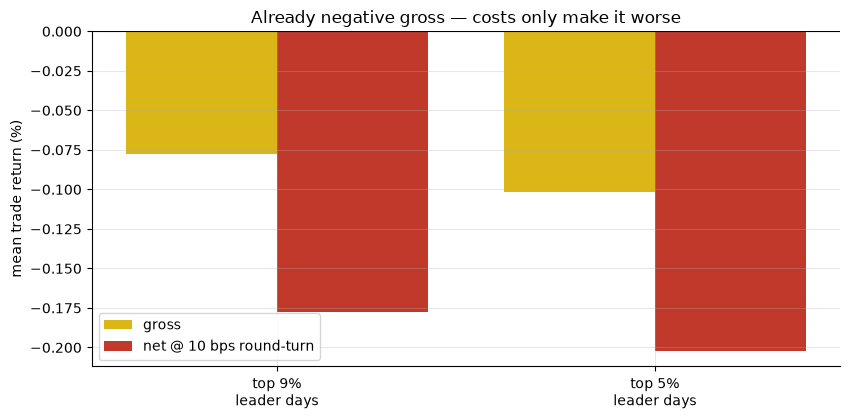

gross/net per trade (%): [(-0.078, -0.178), (-0.102, -0.202)]


In [5]:
if HAVE_REAL:
    rows = []
    for q in (0.90, 0.95):
        ev = st.big_leader_days(F, q=q); c = st.net_of_costs(F, ev, 5.0)
        rows.append((q, c['gross_mean']*100, c['net_mean']*100))
else:
    rows = R['net']
qs = [f'top {int((1-q)*100)}%\nleader days' for q,_,_ in rows]
g = [r[1] for r in rows]; nv = [r[2] for r in rows]; x = np.arange(len(qs))
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar(x-.2, g, .4, color=AMBER, label='gross')
ax.bar(x+.2, nv, .4, color=RED, label='net @ 10 bps round-turn')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels(qs)
ax.set_ylabel('mean trade return (%)')
ax.set_title('Already negative gross — costs only make it worse'); ax.legend()
plt.tight_layout(); plt.show()
print('gross/net per trade (%):', [(round(r[1],3), round(r[2],3)) for r in rows])

The honest bottom line: there is **no toll low enough** to rescue a rule that already loses money gross. Costs aren't the villain here — they're just the final nail. The tradable lead the folklore promises doesn't exist on daily bars, so there's nothing for costs to eat into.

## 7 · Going further 🚪

- **Where the real lead-lag hides.** It's **intraday** — measured in minutes and arbitraged away within the trading day by index-arbitrage desks. With tick data you'd see a genuine leader→member lead; by the daily close it's gone. That's the real lesson: *the clock matters more than the pattern.*
- **The liquidity angle.** [Study 140 — Amihud-Illiquidity](../140-amihud-illiquidity/) asks whether illiquidity itself — the thing that makes members 'slow' — is a priced, tradable factor.
- **Try your own basket.** Swap our 37 names for a different sector or size bucket and re-run the profile — the same-day bar stays tall, the k=+1 bar stays flat.

*Think there's a tradable daily lead? Capture the big-leader days, buy the laggards tomorrow, draw the same number of random next-days, and show the rule landing **outside** the cloud — on the *profitable* side. Then we'll talk.*